In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [28]:
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [29]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.info()

Dataset Shape: (920, 16)

Missing Values:

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611

In [30]:
df = df.drop(['id','dataset'], axis=1)

In [31]:
df_temp = df.fillna(0)

df_encoded = pd.get_dummies(df_temp, drop_first=True)

X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

acc_before = accuracy_score(y_test, pred)
precision_before = precision_score(y_test, pred, average='weighted')
recall_before = recall_score(y_test, pred, average='weighted')
f1_before = f1_score(y_test, pred, average='weighted')

print("Before Cleaning")
print("Accuracy:", acc_before)
print("Precision:", precision_before)
print("Recall:", recall_before)
print("F1 Score:", f1_before)

Before Cleaning
Accuracy: 0.5543478260869565
Precision: 0.4968959175058795
Recall: 0.5543478260869565
F1 Score: 0.5028107966086443


In [32]:
df_cleaned = df.copy()

for col in df_cleaned.columns:
    if col != 'num':
        if df_cleaned[col].dtype == 'object':
            df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
        else:
            df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

C:\Users\srv00\AppData\Local\Temp\ipykernel_31312\2363503581.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])


In [33]:
df_cleaned_encoded = pd.get_dummies(df_cleaned, drop_first=True)

In [34]:
X2 = df_cleaned_encoded.drop('num', axis=1)
y2 = df_cleaned_encoded['num']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model2.fit(X_train2, y_train2)

pred2 = model2.predict(X_test2)

acc_after = accuracy_score(y_test2, pred2)
precision_after = precision_score(y_test2, pred2, average='weighted')
recall_after = recall_score(y_test2, pred2, average='weighted')
f1_after = f1_score(y_test2, pred2, average='weighted')

print("After Cleaning")
print("Accuracy:", acc_after)
print("Precision:", precision_after)
print("Recall:", recall_after)
print("F1 Score:", f1_after)

After Cleaning
Accuracy: 0.5652173913043478
Precision: 0.5012931556021618
Recall: 0.5652173913043478
F1 Score: 0.5140136643875021


In [35]:
param_grid = {
    'n_estimators': [50,100,150],
    'max_depth': [5,10,15],
    'min_samples_split': [2,5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train2, y_train2)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

pred3 = best_model.predict(X_test2)

acc_tuned = accuracy_score(y_test2, pred3)
precision_tuned = precision_score(y_test2, pred3, average='weighted')
recall_tuned = recall_score(y_test2, pred3, average='weighted')
f1_tuned = f1_score(y_test2, pred3, average='weighted')

print("After Hyperparameter Tuning")
print("Accuracy:", acc_tuned)
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1 Score:", f1_tuned)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}
After Hyperparameter Tuning
Accuracy: 0.5380434782608695
Precision: 0.4481561647783961
Recall: 0.5380434782608695
F1 Score: 0.4537385955196128


C:\Users\srv00\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [36]:
print("\nClassification Report:\n")
print(classification_report(y_test2, pred3))


Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.93      0.77        75
           1       0.38      0.52      0.44        54
           2       0.50      0.04      0.07        25
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00         4

    accuracy                           0.54       184
   macro avg       0.31      0.30      0.26       184
weighted avg       0.45      0.54      0.45       184



C:\Users\srv00\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\srv00\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\srv00\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Confusion Matrix:
 [[70  5  0  0  0]
 [26 28  0  0  0]
 [ 5 18  1  1  0]
 [ 4 21  1  0  0]
 [ 1  2  0  1  0]]


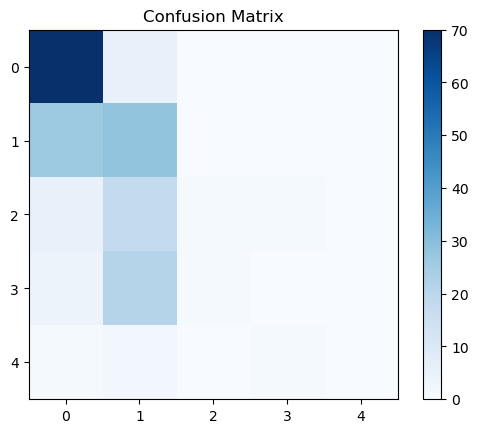

In [38]:
cm = confusion_matrix(y_test2, pred3)

print("Confusion Matrix:\n", cm)

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()
